![Py4Eng](../logo.png)

# Animal Re-Identification — solution
## Yoav Ram

The hybrid re-ranking exercise from [`sessions/reid.ipynb`](../sessions/reid.ipynb).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns

sns.set(style='white', context='talk')
DATA = Path('../data')

turtles = pd.read_csv(DATA / 'turtle_catalogue.csv')
hybrid = np.load(DATA / 'turtle_lightglue_topk.npz')
query_rows = hybrid['query_rows']
shortlist = hybrid['shortlist']
embedding_similarity = hybrid['embedding_similarity']
local_score = hybrid['lightglue_score']

identity = turtles.identity.to_numpy()
correct = identity[shortlist] == identity[query_rows][:, None]
role = turtles.role.to_numpy()[query_rows]
reported, tune_queries = role == 'train', role == 'tune'


def top1(chosen, mask):
    return correct[mask][np.arange(mask.sum()), chosen[mask]].mean()

## TODO 1 — re-rank by the local match score

In [2]:
embedding_top1 = top1(np.zeros(len(shortlist), dtype=int), reported)
reranked_top1 = top1(local_score.argmax(axis=1), reported)
ceiling = correct[reported].any(axis=1).mean()

print(f'embedding alone : {embedding_top1:.3f}')
print(f'local re-rank   : {reranked_top1:.3f}')
print(f'shortlist ceiling: {ceiling:.3f}')
print(f'closes {(reranked_top1 - embedding_top1) / (ceiling - embedding_top1):.0%} '
      'of the gap to the ceiling')

embedding alone : 0.250
local re-rank   : 0.369
shortlist ceiling: 0.476
closes 53% of the gap to the ceiling


## TODO 2 — fuse the two scores, with the weight chosen on the tune individuals

weight chosen on tune: 0.9
fused, reported      : 0.369   (embedding alone 0.250)


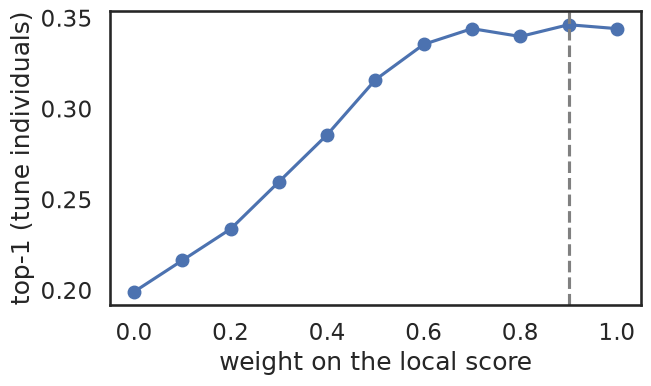

In [3]:
def standardize(x):
    return (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-9)


def fused_choice(w):
    return (standardize(embedding_similarity) * (1 - w) + standardize(local_score) * w).argmax(axis=1)


weights = np.arange(0, 1.01, 0.1)
tune_curve = [top1(fused_choice(w), tune_queries) for w in weights]
best_w = weights[int(np.argmax(tune_curve))]
fused_top1 = top1(fused_choice(best_w), reported)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(weights, tune_curve, marker='o')
ax.axvline(best_w, color='gray', ls='--')
ax.set(xlabel='weight on the local score', ylabel='top-1 (tune individuals)')
fig.tight_layout()

print(f'weight chosen on tune: {best_w:.1f}')
print(f'fused, reported      : {fused_top1:.3f}   (embedding alone {embedding_top1:.3f})')

The curve is flat above about 0.6, and the selected weight puts almost all of it on the local score —
fusion is barely better than dropping the embedding score from the ranking altogether, once the
shortlist has been retrieved. The embedding's job here was recall, not precision.

## Where does the gain come from?

The tempting comparison — gain per group — is confounded, because the groups do not have the same
amount of gain *available*. So we report the headroom too.

In [4]:
database = turtles[turtles.arm_time == 'database']
per_identity = database.identity.value_counts()
available = per_identity.reindex(identity[query_rows]).fillna(0).to_numpy()

bins = [0, 3, 6, 12, 25, 10_000]
labels = ['1-3', '4-6', '7-12', '13-25', '26+']
group = pd.cut(available[reported], bins=bins, labels=labels, right=True)

rows = np.arange(reported.sum())
grouped = pd.DataFrame({
    'group': group,
    'embedding': correct[reported][rows, 0],
    'hybrid': correct[reported][rows, local_score[reported].argmax(axis=1)],
    'ceiling': correct[reported].any(axis=1),
}).groupby('group', observed=True)

table = grouped.mean()
table['queries'] = grouped.size()
table['gain'] = table['hybrid'] - table['embedding']
table['headroom'] = table['ceiling'] - table['embedding']
table['gain / headroom'] = table['gain'] / table['headroom']
table[['queries', 'embedding', 'hybrid', 'ceiling', 'gain', 'headroom', 'gain / headroom']].round(3)

,queries,embedding,hybrid,ceiling,gain,headroom,gain / headroom
group,,,,,,,
1-3,87,0.080,0.172,0.184,0.092,0.103,0.889
4-6,185,0.086,0.141,0.195,0.054,0.108,0.500
7-12,633,0.150,0.246,0.336,0.096,0.186,0.517
13-25,829,0.255,0.369,0.498,0.115,0.244,0.470
26+,844,0.373,0.530,0.649,0.156,0.276,0.567


Read the last two columns against each other, because they tell opposite stories.

The raw **gain** grows with the number of database photographs: +0.16 for individuals with 26 or more,
+0.09 for those with three or fewer. Taken at face value that says local matching helps least exactly
where we hoped it would help most.

But those groups had different amounts of gain on offer. The rarest individuals start with a shortlist
that contains the right answer only 18% of the time, so 0.09 was most of what was there to win. As a
fraction of headroom the ordering reverses: local matching recovers about **89%** of the achievable
gain for individuals with three or fewer photographs, against roughly half for every other group.

That is the result the section predicted, but it is only visible after dividing by a ceiling — and the
undivided version of the same table supports the opposite conclusion just as confidently.

## TODO 3 (extra) — normalize the correspondence count

The raw count favours large, sharp crops with many detectable keypoints. Dividing by the number of
keypoints ALIKED actually found is the cheapest correction; RANSAC inlier counting is the expensive one.

In [5]:
# How many keypoints ALIKED actually found in each image, shipped alongside the match
# scores so that the 2.8 GB feature cache does not have to be.
normalizer = np.sqrt(hybrid['keypoints_shortlist'] * hybrid['keypoints_query'][:, None])
normalized_top1 = top1((local_score / normalizer).argmax(axis=1), reported)

print('keypoints per image: {} to {}'.format(
    hybrid['keypoints_query'].min(), hybrid['keypoints_query'].max()))
print(f'raw count       : {reranked_top1:.3f}')
print(f'normalized count: {normalized_top1:.3f}')

keypoints per image: 1 to 800
raw count       : 0.369
normalized count: 0.369


ALIKED was given a budget of 800 keypoints and most of these crops hit it, so within a shortlist there
is usually little left for the normalization to correct and the two scores rank almost identically.
The images that fall well short of the budget are the small, blurred crops — exactly the ones where
the raw count was already going to be low. On a corpus with more variable image quality, dividing by
the keypoint count matters more than it does here.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)